# New_Apple_Import Py File

## Uploading New Apple Raw Data

In [3]:
import os
import datetime as dt
import sys
import pandas as pd
from sqlalchemy import create_engine, text
import time
import numpy as np
from zoneinfo import ZoneInfo
from datetime import datetime

engine = create_engine(f"sqlite:///habits.db")

# def max_date():

# Read from SQLite and parse those columns as datetime
with engine.connect() as connection:
    max_date_db = pd.read_sql_query(
        text("""SELECT MAX(DATETIME(adr.startDate)) as 'Max_Raw_UTC_Start_Date'
                FROM apple_data_raw adr"""), 
        connection,
        parse_dates=['Max_Raw_UTC_Start_Date'])   


max_date_db["Max_Raw_UTC_Start_Date"] = (
    pd.to_datetime(max_date_db["Max_Raw_UTC_Start_Date"])
    .dt.tz_localize("UTC"))

max_UTC_date_db = max_date_db["Max_Raw_UTC_Start_Date"].iloc[0]

In [4]:
# def upload_new_raw_apple_data(inital_max_date):

import pandas as pd
import os 
# ETL step of gathering new data from apple health and upploading it almost as it is apple_data_raw

# Defining the subddirectroy where apple docs live
directory = "apple/"

# Initializing variable
apple_file = "apple_health_export_2025-12-14.csv"

# Read in new CSV File, low_memory=False to avoid dtype warnings
apple = pd.read_csv(os.path.join(directory, apple_file), low_memory=False)

# Fitler the source to only my Apple Watch (Could pull in other devices later like iPhone or gamin)
apple = apple[(apple['sourceName'] == "Ryan’s Apple\xa0Watch") | (apple['sourceName'].isna())]

# Strip the "HKWorkoutActivityType" prefix from the workout types
apple["workoutActivityType"] = apple["workoutActivityType"].str.replace("HKWorkoutActivityType", "")

# Drop the UUID column, apple added this since last 7/18 upload
apple.drop(columns=['uuid'], inplace=True)

# Creating a copy of apple dataframe to avoid settingwithcopy warnings when converting datetime
apple_copied = apple.copy()

del apple

# Convert date columns to datetime format (took 16 min to run on 2.4 million rows)
datetime_cols = ['startDate', 'endDate', 'creationDate']
for col in datetime_cols:
    apple_copied[col] = pd.to_datetime(apple_copied[col], format='%Y-%m-%d %H:%M:%S %z', utc=True)

# Using the exisiting max date in my db to filter to only new data from apple 
apple_copied = apple_copied[apple_copied["startDate"] > max_UTC_date_db] # dt_utc_test  max_UTC_date_db

In [6]:
max(apple_copied["startDate"])

Timestamp('2025-12-14 20:17:22+0000', tz='UTC')

In [7]:
# Appending the actually new raw data to the apple_data_raw table
apple_copied.to_sql(name="apple_data_raw", con=engine, if_exists='append', index=False)

53615

In [8]:
# Filler UTC Datetime variable for testing purposes
from datetime import datetime, timezone

dt_utc_test = datetime(2025, 12, 10, tzinfo=timezone.utc)
max_UTC_date_db = dt_utc_test

## Converting Apple Raw Data to Apple workouts data 

In [9]:
import os
import datetime as dt
import sys
import pandas as pd
from sqlalchemy import create_engine, text
import time
import numpy as np
from zoneinfo import ZoneInfo
from datetime import datetime

engine = create_engine(f"sqlite:///habits.db")


#def Read_Apple_Workouts(max_date_utc):

# Reading in only the newly updated data from apple_data_raw (using inital max_UTC_date_db prior to uploading new raw data)
with engine.connect() as connection: 
    apple_raw = pd.read_sql_query( 
        text("""SELECT workoutActivityType, startDate, type, maximum, minimum, sum, average, duration, durationUnit 
        FROM apple_data_raw
        WHERE StartDate > :max_date"""),
        connection,
        params={"max_date": str(max_UTC_date_db)}, # Using the str version of the datetime for 
        parse_dates=['startDate']) # Parse date here takes out need for pd.to_datetime below 

apple_raw["startDate"] = apple_raw["startDate"].dt.tz_localize("UTC")

# Filters df to include only rows where at least one of the workout-related columns is not missing (NaN).
# .notna() Check for Non-Nulls in selected columns 
# .any(axis=1) aggregates rows where there's at least one non-missing value 
apple_workouts = apple_raw[apple_raw.notna().any(axis=1)] 

In [10]:
#def aw_to_long(apple_workouts):

# Reshape the apple_workouts DataFrame from wide format (one row per workout with multiple measurement columns) to long format (one row per measurement per workout).
df_long = pd.melt(apple_workouts, 
                    id_vars=['startDate', 'workoutActivityType', 'type', 'duration', 'durationUnit'],
                    value_vars=['maximum', 'minimum', 'sum', 'average'], # turned into rows via where the name goes into 'measurement_type' and actual values to the 'value' column
                    var_name='measurement_type', 
                    value_name='value')

# Removing rows where either type or value are null (no meaningful data here)
df_long = df_long[(df_long['type'].notna()) | (df_long['value'].notna())]

# Handle duration rows separately and combine
duration_rows = apple_workouts[apple_workouts['duration'].notna() & apple_workouts['type'].isna()].copy()
duration_rows = duration_rows.assign(
    measurement_type='total',
    value=duration_rows['duration'],
    type='Duration')[['startDate', 'workoutActivityType', 'type', 'measurement_type', 'value', 'durationUnit']]

# Combine and clean
result = pd.concat([df_long[df_long['value'].notna()][['startDate', 'workoutActivityType', 'type', 'measurement_type', 'value', 'durationUnit']],
    duration_rows], ignore_index=True)

# Rename columns for clarity
result.rename(columns={'startDate': 'StartDate', 'workoutActivityType': 'activity', 'type': 'metric', # Why do I rename StartDate to be different than apple data raw?
                       'measurement_type': 'measurement_type', 'value': 'value', 'durationUnit': 'd_unit'}, inplace=True)

# cleaning value column to only go out 2 decimal places
result['value'] = result['value'].round(2)

result.sort_values('StartDate', ascending=False, inplace=True)

In [17]:
def max_workout_id():
        #Gathering the max workout_id from existing apple_workouts table
        with engine.connect() as connection:
                max_workout_id_df = pd.read_sql_query(
                        text("""SELECT max(workout_id) as workout_id 
                                FROM apple_workouts
                                WHERE activity IS NOT NULL"""), # Need to filter on activity because otherwise workout_id is NA
                        connection)  

                # Grabbing singlular max workout_id from dataset to filter new data off of  
                max_workout_id = int(max_workout_id_df['workout_id'][0]) # Maybe make this an INT variable?

        return max_workout_id

#max_workout_id = max_workout_id()

In [13]:
aw_long = result.copy()

In [48]:
#def add_workout_id(aw_long):

# We're able to easily get unique workouts by date because aw_long only has activity filled for the duration metric which every workout has 1 of 
activity_map = aw_long[aw_long['activity'].notnull()][["StartDate", "activity"]]

# Sorting values by date and resetting index (easy way to grab a unique id so long as I'm sorting correctly)
activity_map = activity_map.sort_values('StartDate').reset_index(drop=True)

# Creating a new variable based on the index  
# Previous null values probably from Garmin are keeping workout_id from being an integer in aw_final
activity_map['workout_id'] = activity_map.index.astype(int) + max_workout_id()  # Start IDs from 1

# Merge activity back onto the main dataframe using startDate
aw_final = pd.merge(aw_long, activity_map, on='StartDate', how='left', suffixes=('', '_Specifier'))

# Drop the original activity column
aw_final.drop(columns=['activity'], inplace=True)

# Rename the helper column to activity since that's actually what we'll want
aw_final.rename(columns={'activity_Specifier': 'activity'}, inplace=True)

In [49]:
# Adding new activity type variable for minutes calculation 
aw_final['activity_type'] = np.where(aw_final['activity'].isin(['Running', 'Cycling', 'Swimming', 'Walking']), 'Cardio',
    np.where(aw_final['activity'] == 'TraditionalStrengthTraining', 'Weights', None))

# need to do a couple of string conversions before uploading the data to the sql lite db
#aw_final['month'] = aw_final['month'].astype(str) # Shouldn't need this
#aw_final['workout_id'] = aw_final['workout_id'].astype('Int64').astype(str) # Not good



In [50]:
#def final_upload(aw_final):

aw_final.to_sql(name="apple_workouts", con=engine, if_exists='append', index=False) 

28

# Data Cleaning PY

In [28]:
import os
import datetime as dt
import sys
import pandas as pd
from sqlalchemy import create_engine, text
import time
import numpy as np
from zoneinfo import ZoneInfo
from datetime import datetime

# Read in cleaned Apple Workouts data 
#def Read_Apple_Workouts():

engine = create_engine(f"sqlite:///habits.db")

# Read in the data and parse datetime columns
with engine.connect() as connection:
    aw_all = pd.read_sql_query(
        text("""SELECT * FROM apple_workouts"""),
        connection)
        #dtype={"workout_id": "Int64"}) # Converting workout_id to Int64 upon entry, will need again if workout_id includes blanks
    
# Converting the string datetime variable from db to with timezone normalization to UTC then converting to EST
# This is needed because of combination of EST and EDT in the data 
date_cols = ["StartDate"]
for col in date_cols:
    aw_all[col] = (
        pd.to_datetime(aw_all[col])
        .dt.tz_localize("UTC")
        .dt.tz_convert("US/Eastern")
)

# calculating out necessary time metrics when reading in apple workouts data
## calculates how many days each weekday is from monday and subtracts that from the orignal date to get back to start of the week Monday
aw_all['week_period'] = (
    aw_all['StartDate']
      - pd.to_timedelta(aw_all['StartDate'].dt.weekday, unit="D") # dt.weekday uses Monday as 0 
).dt.date

## Extract Year-Month for grouping
#aw_final['month'] = aw_final['StartDate'].dt.to_period('M')

aw_all['month'] = aw_all['StartDate'].dt.strftime('%b %Y') # Need .dt for series/panda 

In [30]:
# Set 'month_label' as a categorical(factor variable) with order based on 'month_period'
month_order = aw_all.sort_values('month')['StartDate'].unique()

<DatetimeArray>
['2024-04-01 07:42:45-04:00', '2024-04-22 07:52:21-04:00',
 '2024-04-22 14:26:01-04:00', '2024-04-20 15:08:24-04:00',
 '2024-04-20 07:52:25-04:00', '2024-04-20 14:39:55-04:00',
 '2024-04-28 13:40:19-04:00', '2024-04-28 13:49:46-04:00',
 '2024-04-29 07:47:34-04:00', '2024-04-24 07:49:45-04:00',
 ...
 '2025-09-29 17:42:24-04:00', '2025-09-04 06:46:45-04:00',
 '2025-09-06 08:35:11-04:00', '2025-09-06 15:31:08-04:00',
 '2025-09-27 09:06:06-04:00', '2025-09-25 19:19:35-04:00',
 '2025-09-28 09:29:41-04:00', '2025-09-21 10:06:22-04:00',
 '2025-09-14 14:51:32-04:00', '2025-09-25 06:41:18-04:00']
Length: 524, dtype: datetime64[ns, US/Eastern]

In [ ]:

month_count_data['month_label'] = pd.Categorical(month_count_data['month_label'], categories=month_order, ordered=True)  # Convert to int for better readability

## DFs for individual graphs

In [26]:
from itertools import product
# Function that fills in missing data for each grouped by df 
def fill_missing_combinations(
    original_df,
    aggregated_df,
    time_col,
    category_col,
    value_cols,
    time_filter=None,
    category_values=None):

    # Step 1: Filter time periods if needed
    if time_filter:
        time_values = original_df[time_filter(original_df)].loc[:, time_col].unique()
    else:
        time_values = original_df[time_col].unique()
    # Step 2: Get all categories
    if category_values:
        category_values = category_values
    else:
        category_values = aggregated_df[category_col].unique()
    # Step 3: Create full index
    full_index = pd.DataFrame(
        product(category_values, time_values),
        columns=[category_col, time_col])
    # Step 4: Merge with aggregated data
    filled_df = pd.merge(full_index, aggregated_df, on=[category_col, time_col], how='left')
    # Step 5: Fill NaNs with 0 for specified value columns
    for col in value_cols:
        filled_df[col] = filled_df[col].fillna(0)

    return filled_df.sort_values(by=[time_col, category_col]).reset_index(drop=True)

### Time Filters

In [14]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
from zoneinfo import ZoneInfo

today = datetime.now(tz=ZoneInfo("US/Eastern"))

l_3_m = today - relativedelta(weeks=14)
l_7_m = today - relativedelta(months=7)
l_1_y = today - relativedelta(years=1)

In [ ]:
activities = ["Walking", "Cycling", "TraditionalStrengthTraining", "Running", "Swimming"]

df_counts = (aw_all[(aw_all['metric'] == 'Duration') & (aw_all['activity'].isin(activities)) & (aw_all['month'] > str(l_7_m))] # Convert datetime to string for comparison
    .groupby(['month', 'activity'])
    .size()
    .reset_index(name='n'))

#### Getting stuck on how I want to show month in the graph and how much if at all I use StartTime as dateimte variable 

In [ ]:
############### Frequency bar chart grouped by exercise type and month ###############
#gen_month_freq_df(aw_final, l_7_m)

activities = ["Walking", "Cycling", "TraditionalStrengthTraining", "Running", "Swimming"]

df_counts = (aw_all[(aw_all['metric'] == 'Duration') & (aw_all['activity'].isin(activities)) & (aw_all['month'] > str(l_7_m))] # Convert datetime to string for comparison
    .groupby(['month', 'activity'])
    .size()
    .reset_index(name='n'))

month_count_data = fill_missing_combinations(
    original_df=df_counts,
    aggregated_df=df_counts,
    time_col='month',
    category_col='activity',
    value_cols=['n'])

month_count_data['n'] = month_count_data['n'].astype(int)  # Convert to int for better readability

# Create a string label for display
month_count_data['month_label'] = month_count_data['month'].dt.strftime('%b %Y')

# Set 'month_label' as a categorical(factor variable) with order based on 'month_period'
month_order = month_count_data.sort_values('month')['month_label'].unique()
month_count_data['month_label'] = pd.Categorical(month_count_data['month_label'], categories=month_order, ordered=True)  # Convert to int for better readability

# Adding a label for 'TraditionalStrengthTraining' top shorten it for the graph output
month_count_data['activity'] = month_count_data['activity'].replace({'TraditionalStrengthTraining': 'Weights'})

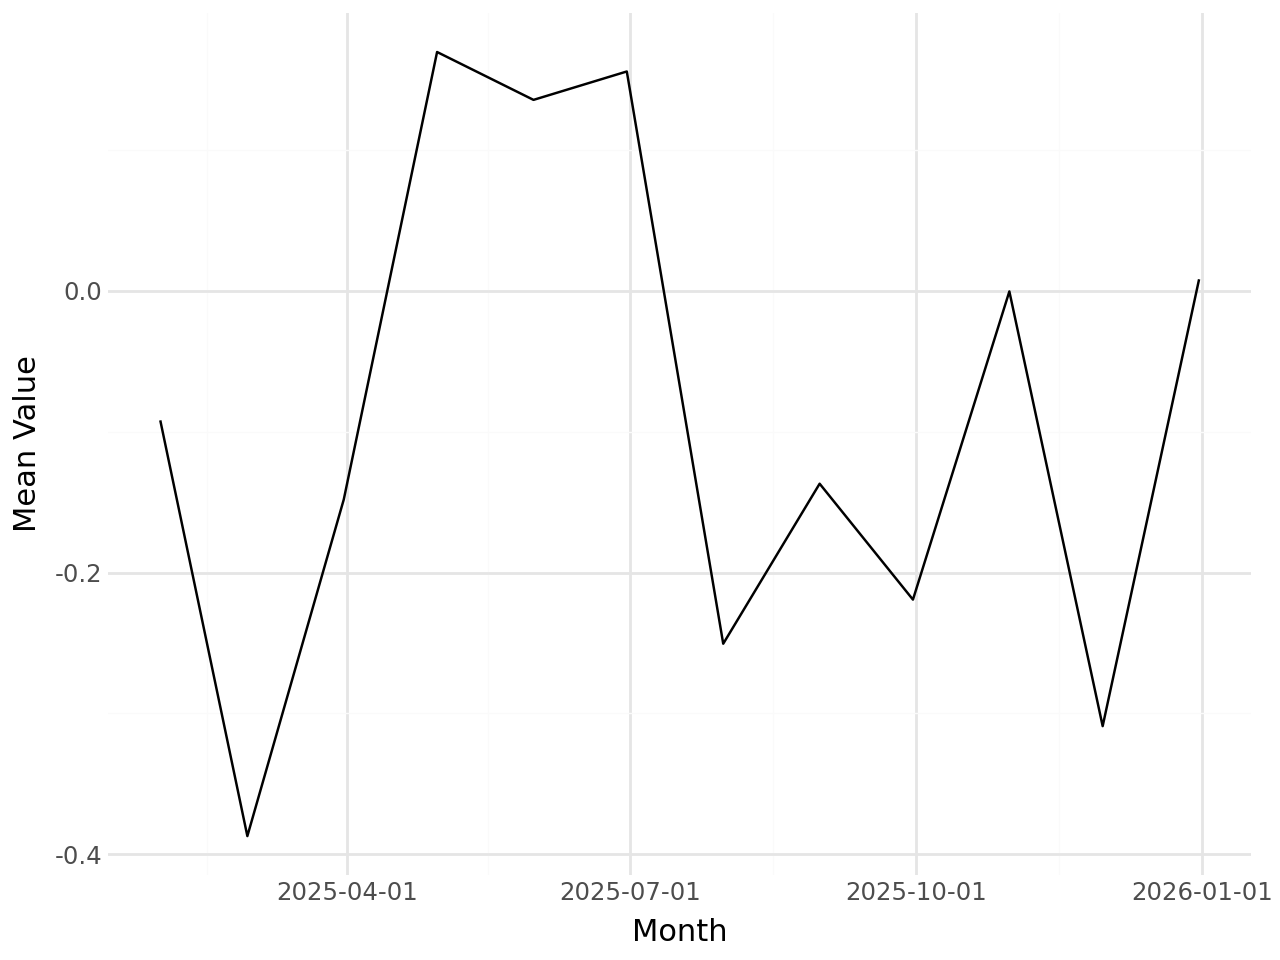

In [2]:
import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_line, labs, scale_x_datetime, theme_minimal

# Example dataframe
df = pd.DataFrame({
    'datetime': pd.date_range(start='2025-01-01', end='2025-12-31', freq='D'),
    'value': np.random.randn(365)
})

# Option 1: Aggregate by month using pd.Grouper
df_month = df.groupby(pd.Grouper(key='datetime', freq='ME')).mean().reset_index()

# Plot
p = (
    ggplot(df_month, aes(x='datetime', y='value')) +
    geom_line() +
    #scale_x_datetime(date_labels='%b %Y') +
    labs(x='Month', y='Mean Value') +
    theme_minimal()
)
p


In [ ]:






############### Frequency bar chart grouped by exercise type and week ###############
def gen_week_freq_df(aw_final, filter2):
    activities = ["Walking", "Cycling", "TraditionalStrengthTraining", "Running", "Swimming"]

    df_counts = (aw_final[(aw_final['metric'] == 'Duration') & (aw_final['activity'].isin(activities)) & (aw_final['StartDate'] >= filter2)]
        .groupby(['week_period', 'activity'])
        .size()
        .reset_index(name='n'))
    
    week_count_data = fill_missing_combinations(
        original_df=df_counts,
        aggregated_df=df_counts,
        time_col='week_period',
        category_col='activity',
        value_cols=['n'])

    week_count_data['n'] = week_count_data['n'].astype(int)  # Convert to int for better readability

    # Create a string label for display
    week_count_data['week_label'] = week_count_data['week_period'].dt.strftime('%b %d')

    # Set 'week_label' as a categorical(factor variable) with order based on 'week_period'
    week_order = week_count_data.sort_values('week_period')['week_label'].unique()
    week_count_data['week_label'] = pd.Categorical(week_count_data['week_label'], categories=week_order, ordered=True)

    # Adding a label for 'TraditionalStrengthTraining' top shorten it for the graph output
    week_count_data['activity'] = week_count_data['activity'].replace({'TraditionalStrengthTraining': 'Weights'})

    return week_count_data






############### Distance per week grouped by exercise type ###############
def gen_distance_df(aw_final, filter2):

    miles_week = (aw_final[(aw_final['activity'].isin(['Running', 'Cycling'])) & (aw_final['metric'].str.contains("Distance")) & (aw_final['StartDate'] >= filter2)]
        .groupby(['activity', 'week_period'])['value']
        .agg(Total_Miles='sum', n='count')  # compute both mean and count
        .round(2) # Round to 2 decimal places
        .reset_index())


    full_miles_week = fill_missing_combinations(
        original_df=aw_final,
        aggregated_df=miles_week,
        time_col='week_period',
        category_col='activity',
        value_cols=['Total_Miles', 'n'],
        time_filter=lambda df: df['StartDate'] > filter2,
        category_values=['Running', 'Cycling'])
        
        # Create a string label for display
    full_miles_week['week_label'] = full_miles_week['week_period'].dt.strftime('%b %d')

    # Set 'week_label' as a categorical(factor variable) with order based on 'week_period'
    week_order = full_miles_week.sort_values('week_period')['week_label'].unique()
    full_miles_week['week_label'] = pd.Categorical(full_miles_week['week_label'], categories=week_order, ordered=True)

    
    return full_miles_week


############### Minutes per week grouped by cardio and weights ###############
def gen_mins_df(aw_final, filter2):

    mins_week = (aw_final[
            (aw_final['activity_type'].notna()) &
            (aw_final['metric'] == "Duration") &
            (aw_final['StartDate'] >= filter2)]
        .groupby(['activity_type', 'week_period'])['value']
        .agg(Total_min='sum', n='count')  # compute sum and count
        .round(2)  # Round to 2 decimal places
        .reset_index())

    full_mins_week = fill_missing_combinations(
        original_df=aw_final,
        aggregated_df=mins_week,
        time_col='week_period',
        category_col='activity_type',
        value_cols=['Total_min', 'n'],
        time_filter=lambda df: df['StartDate'] > filter2,
        category_values=['Cardio', 'Weights'])
    
        
    # Create a string label for display
    full_mins_week['week_label'] = full_mins_week['week_period'].dt.strftime('%b %d')

    # Set 'week_label' as a categorical(factor variable) with order based on 'week_period'
    week_order = full_mins_week.sort_values('week_period')['week_label'].unique()
    full_mins_week['week_label'] = pd.Categorical(full_mins_week['week_label'], categories=week_order, ordered=True)
    
    return full_mins_week


############### Minutes per week for all exercises ############### 
def gen_workout_time_df(aw_final, filter1):
    workout_time = aw_final[(aw_final['month'] > filter1) & 
                            (aw_final['metric'] == 'Duration')].groupby(['week_period'])['value'].agg(Time='sum', n='count').reset_index()
    workout_time['Time'] = workout_time['Time'].round(2)

    return workout_time


############### Activity Treemap ###############  
def gen_activity_treemap_df(aw_final, filter2):

    activites = ['Running', 'Cycling', 'TraditionalStrengthTraining', 'Swimming']

    activity_distribution = (aw_final[
            (aw_final['metric'] == "Duration") & 
            (aw_final['activity'].isin(activites)) & 
            (aw_final['StartDate'] >= filter2)]
        .sort_values(by='StartDate', ascending=False)
        .groupby(['activity'])['value']
        .agg(count='count')
        .reset_index())
                
    # Add percent of total column
    total = activity_distribution['count'].sum()
    activity_distribution['percent'] = activity_distribution['count'] / total

    # Format labels as "Activity<br>Count (Percent)"
    activity_distribution['label'] = activity_distribution.apply(lambda row: f"{row['activity']}<br>{row['count']} ({row['percent']:.1%})", axis=1)

    return activity_distribution


############### Steps per day boxplot ###############
def gen_steps_month_df(filter3):

    # Read from SQLite and parse those columns as datetime
    with engine.connect() as connection:
        apple = pd.read_sql_query(
            text("""SELECT type, value, startDate, endDate 
                FROM apple_data_raw
                WHERE type = 'StepCount' AND value IS NOT NULL and startDate >= :t_filter
                ORDER BY startDate DESC"""), connection,
            params={"t_filter": filter3},
            parse_dates=['startDate', 'endDate'])
        
    apple["startDate"] = (pd.to_datetime(
        apple["startDate"],
        format="ISO8601"
    ).tz_convert("America/New_York"))

    apple['value'] = apple['value'].astype(float)
        

    # Group by date (not datetime)
    steps_day = apple.groupby(apple['startDate'].dt.date)['value'].agg(steps='sum', n='count').reset_index()

    # Convert 'startDate' to datetime
    steps_day['startDate'] = pd.to_datetime(steps_day['startDate'])

    # Extract month as a period for correct ordering
    steps_day['month_period'] = steps_day['startDate'].dt.to_period('M')

    # Create a string label for display
    steps_day['month_label'] = steps_day['month_period'].dt.strftime('%b %Y')

    # Set 'month_label' as a categorical(factor variable) with order based on 'month_period'
    month_order = steps_day.sort_values('month_period')['month_label'].unique()
    steps_day['month_label'] = pd.Categorical(steps_day['month_label'], categories=month_order, ordered=True)

    return steps_day



############### KPI Statisitcs Functions ###############

# Going to have to recreate this function with apple workout data
def get_kpi_stats(steps_day):

    # Get this month and last month as Periods
    this_month = today.to_period('M')
    last_month = (today - pd.DateOffset(months=1)).to_period('M')
    three_mon_ago = (today - pd.DateOffset(months=3)).normalize() # Normalize sets the time to midnight


    # Since I just want to get straight count numbers for this db, I can use the shape funciton to get row count
    wokrout_count_CM = aw_final[(aw_final['month'] == this_month) & (aw_final['metric'] == 'Duration')].shape[0]
    workout_count_LM = aw_final[(aw_final['month'] == last_month) & (aw_final['metric'] == 'Duration')].shape[0]
    workout_count_year = aw_final[(aw_final['StartDate'].dt.year >= 2025) & (aw_final['metric'] == 'Duration')].shape[0]

    # Average daily step count last 3 months
    steps_L3_mon = steps_day[steps_day["startDate"] >= three_mon_ago]
    steps_L3_mon = steps_L3_mon["steps"].mean().round(0).astype("int")

    # Gather workout time metrics
    workout_time = aw_final[(aw_final['metric'] == 'Duration')].groupby(['week_period'])['value'].agg(Time='sum', n='count').reset_index()
    workout_time = workout_time[workout_time["week_period"] >= three_mon_ago] # Taking the last 3 months of data 
    workout_time_hrs_avg = (workout_time["Time"].mean()/60).round(2) 

    # Gather names for above statistic

    current_month_name = today.month_name()
    last_month_name = (today - pd.DateOffset(months=1)).strftime('%B')  

    return workout_count_year, workout_count_LM, wokrout_count_CM, current_month_name, last_month_name, workout_time_hrs_avg, steps_L3_mon



# Visualization Py

In [ ]:
############### Frequency bar chart grouped by exercise type and month ###############
month_count_data = gen_month_freq_df(aw_final, l_7_m)

def Monthly_Freq_BarChart():
        
    plot = (ggplot(month_count_data, aes(x='month_label', y='n', fill='activity')) + 
        geom_bar(stat='identity', position='dodge', color = "Black") +
        geom_text(aes(label='n'), position=position_dodge(width=0.9), va='bottom') + # va & ha are used for veritcal and horizontal allignment 
        
        scale_fill_brewer(type='qual', palette='Set2') +
        scale_y_continuous(breaks = range(0, 14, 2),
                        limits = [0, 13]) +

        labs(title='Workout Frequency by Month and Activity',
            x='',
            y='Sessions',
            fill='Activity',
            color='Goal') +
        #theme_matplotlib() +
        theme_seaborn() +
        theme(figure_size=(10, 5)))

    # Render plot to a matplotlib figure
    fig = plot.draw()

    # Save figure to buffer
    static_bytes = io.BytesIO()
    fig.savefig(static_bytes, format='png', bbox_inches='tight')
    static_bytes.seek(0)
    static_base64 = base64.b64encode(static_bytes.read()).decode('utf-8')
    frequency_plot_url = f"data:image/png;base64,{static_base64}"
    plt.close(fig)

    return frequency_plot_url 


In [ ]:



############### Frequency bar chart grouped by exercise type and week ###############
week_count_data = gen_week_freq_df(aw_final, l_3_m)

def Weekly_Freq_BarChart():

    plot = (ggplot(week_count_data, aes(x='week_label', y='n', fill='activity')) +
        geom_bar(stat='identity', position='dodge', color = "Black") +
        geom_text(aes(label='n'), position=position_dodge(width=0.9), va='bottom') + # va & ha are used for veritcal and horizontal allignment 
        
        scale_fill_brewer(type='qual', palette='Set2') +
        #scale_color_manual(values={'Running': 'Black', 'Cycling': 'Gray'}) +
        scale_y_continuous(breaks = range(0, 6),
                        limits = [0, 5]) +

        labs(title='Workout Frequency by Week and Activity',
            x='',
            y='Sessions',
            fill='Activity') +
        #theme_matplotlib() +
        theme_seaborn() +
        theme(figure_size=(10, 5)))

    # Render plot to a matplotlib figure
    fig = plot.draw()

    # Save figure to buffer
    static_bytes = io.BytesIO()
    fig.savefig(static_bytes, format='png', bbox_inches='tight')
    static_bytes.seek(0)
    static_base64 = base64.b64encode(static_bytes.read()).decode('utf-8')
    frequency_plot_url = f"data:image/png;base64,{static_base64}"
    plt.close(fig)

    return frequency_plot_url 


############### Distance per week grouped by exercise type ###############
full_miles_week = gen_distance_df(aw_final, l_3_m)

def Distance_BarChart():
        
    plot = (ggplot(full_miles_week, aes(x='week_label', y='Total_Miles', fill='activity')) +
        geom_bar(stat='identity', position='dodge', color = "Black") +
        geom_text(aes(label='Total_Miles'), position=position_dodge(width=.9), va='bottom') +

        scale_y_continuous(breaks = range(0, 36, 5),
                        #minor_breaks=range(0, 36, 2),  # Can't do minor ticks 2.5 because int not float :(
                        limits = [0, 36]) +

        scale_fill_manual(values={'Running': '#a259d9',   
            'Cycling': '#ff9800'}) +

        labs(title= "Cardio Miles per Week",
            x="",
            y="Miles",
            fill = "Activity") +
        theme_seaborn() +
        theme(figure_size=(10, 5),
            panel_grid_minor_y = element_line(color = "White", linetype = "dotted")))

    # Render plot to a matplotlib figure
    fig = plot.draw()

    # Save figure to buffer
    static_bytes = io.BytesIO()
    fig.savefig(static_bytes, format='png', bbox_inches='tight')
    static_bytes.seek(0)
    static_base64 = base64.b64encode(static_bytes.read()).decode('utf-8')
    distance_plot_url = f"data:image/png;base64,{static_base64}"
    plt.close(fig)

    return distance_plot_url


############### Minutes per week grouped by cardio and weights ###############
full_mins_week = gen_mins_df(aw_final, l_3_m)

def Minutes_BarChart():
    plot = (ggplot(full_mins_week, aes(x='week_label', y='Total_min', fill='activity_type')) +
        geom_bar(stat='identity', position='dodge', color = "Black") +
        geom_text(aes(label='Total_min'), format_string='{:.1f}',position=position_dodge(width=.9), va='bottom') + #Format count?

        geom_hline(yintercept=150, color="#549f74", linetype='dashed', size=1) + # Cardio goal
        geom_hline(yintercept=80, color="#b36a62", linetype='dashed', size=1) + # Weights goal
        
        scale_y_continuous(breaks = range(0, 450, 50),
                        #minor_breaks=range(0, 36, 2),  # Can't do minor ticks 2.5 because int not float :(
                        limits = [0, 400]) +

        # Manual color scales
        scale_fill_manual(values={'Cardio': '#52be80', 'Weights': '#ec7063'}) +  # Bar colors
        
        labs(title= "Minutes per Week by Activity",
            x="",
            y="Minutes", 
            fill="Activity") +
        
        theme_seaborn() +
        theme(figure_size=(10, 5),
            panel_grid_minor_y = element_line(color = "White", linetype = "dotted")))
    
    # Render plot to a matplotlib figure
    fig = plot.draw()

    # Save figure to buffer
    static_bytes = io.BytesIO()
    fig.savefig(static_bytes, format='png', bbox_inches='tight')
    static_bytes.seek(0)
    static_base64 = base64.b64encode(static_bytes.read()).decode('utf-8')
    mins_plot_url = f"data:image/png;base64,{static_base64}"
    plt.close(fig)

    return mins_plot_url

############### Minutes per week for all exercises ############### 
workout_time = gen_workout_time_df(aw_final, l_7_m)
 
def Minutes_LineGraph():
    plot = (ggplot(workout_time, aes(x='week_period', y='Time')) +
        geom_line(color = "blue", size = 1) +
        geom_point(aes(size = "n"), alpha = 0.6, color = "blue") +
        geom_text(aes(label='n'), format_string='{:.0f}', va='bottom') +
        labs(title= "Minutes per Week by Activity",
            x="Week",
            y="Minutes") +
        scale_x_datetime(date_labels='%b %d', date_breaks='1 week') +
        
        theme_seaborn() +
        theme(panel_grid_minor_y = element_line(color = "gray", linetype = "dotted"),
            figure_size=(10, 5),
            axis_text_x=element_text(angle=25, hjust=1),
            legend_position='none',
            axis_ticks_minor_x=element_blank()))

    # Render plot to a matplotlib figure
    fig = plot.draw()

    # Save figure to buffer
    static_bytes = io.BytesIO()
    fig.savefig(static_bytes, format='png', bbox_inches='tight')
    static_bytes.seek(0)
    static_base64 = base64.b64encode(static_bytes.read()).decode('utf-8')
    total_mins_plot_url = f"data:image/png;base64,{static_base64}"
    plt.close(fig)

    return total_mins_plot_url


############### Step count grouped by month ############### 
steps_day = gen_steps_month_df(l_1_y)

def Steps_Boxplot():
    plot = (
        ggplot(steps_day, aes(x='month_label', y='steps', fill='month_label')) +

        geom_boxplot(color="black") +
        stat_summary(fun_data="mean_cl_boot", geom = "point", fill = "white", color = "red") +

        labs(title="Daily Steps Grouped by Month", 
            x="", 
            y="Steps") +

        scale_y_continuous(breaks = range(0, 32500, 5000),
                        minor_breaks=range(0, 32500, 2500),  # Can't do minor ticks 2.5 because int not float :(
                        limits = [0, 30000]) +

        theme_seaborn() +

        theme(axis_text_x=element_text(),
            figure_size=(10, 5),
            legend_position='none',
            panel_grid_minor_y = element_line(color = "White", linetype = "dotted")))

    # Render plot to a matplotlib figure
    fig = plot.draw()

    # Save figure to buffer
    static_bytes = io.BytesIO()
    fig.savefig(static_bytes, format='png', bbox_inches='tight')
    static_bytes.seek(0)
    static_base64 = base64.b64encode(static_bytes.read()).decode('utf-8')
    steps_boxplot_url = f"data:image/png;base64,{static_base64}"
    plt.close(fig)

    return steps_boxplot_url



############### Activity Treemap ############### 
activity_distribution = gen_activity_treemap_df(aw_final, l_3_m)

def activity_treemap():
    # Create treemap
    fig = px.treemap(
        activity_distribution,
        path=['label'],         # use custom label for full text
        values='count',
        color='count',
        color_continuous_scale='Blues')
    
    fig.update_traces(hovertemplate='%{label}')  
    fig.update_layout(showlegend=False, coloraxis_showscale=False)

    treemap_plotly_html = pio.to_html(fig, full_html=False)

    return treemap_plotly_html